In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
N = 6
p1, p2 = np.empty((N, 2)), np.empty((N, 2))

(a), (b)

In [15]:
def click_points(img, title, points):
    n = 0
    img_copy = img.copy()
    cv2.namedWindow(title, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(title, 1200, 900)
    
    def callback(event, x, y, flags, param):
        nonlocal n
        if event == cv2.EVENT_LBUTTONDOWN:
            cv2.circle(img_copy, (x, y), 8, (0, 255, 0), -1)
            cv2.putText(img_copy, str(n+1), (x-20, y-15), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
            points[n] = (x, y)
            n += 1
            print(f"Point {n}: ({x}, {y})")
    
    cv2.setMouseCallback(title, callback)
    while n < N:
        cv2.imshow(title, img_copy)
        if cv2.waitKey(20) & 0xFF == 27:
            break
    cv2.destroyWindow(title)
    return points

Click 6 points on Image 1
Point 1: (672, 1147)
Point 2: (1071, 659)
Point 3: (1531, 581)
Point 4: (1584, 1169)
Point 5: (1514, 1876)
Point 6: (934, 1805)

Click same 6 points on Image 2
Point 1: (1067, 533)
Point 2: (1584, 427)
Point 3: (1771, 1132)
Point 4: (1435, 1537)
Point 5: (974, 1558)
Point 6: (743, 1274)


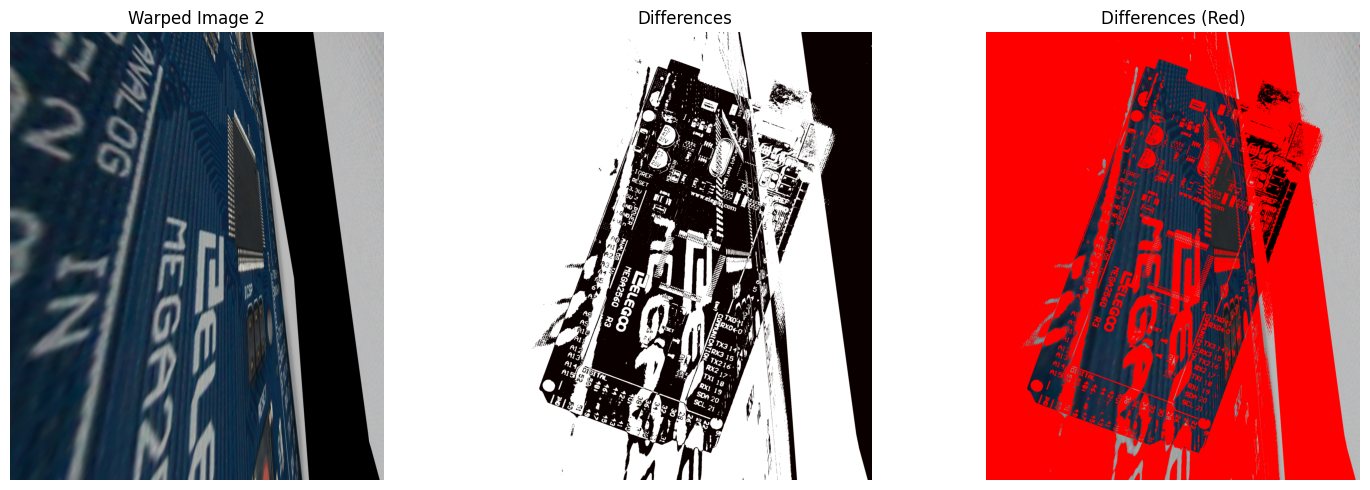


Differing pixels: 3938369 (63.32%)


In [16]:
im1 = cv2.imread('c1.jpg')
im2 = cv2.imread('c2.jpg')
h, w = im1.shape[:2]

print("Click 6 points on Image 1")
p1 = click_points(im1, 'Image 1', p1)
print("\nClick same 6 points on Image 2")
p2 = click_points(im2, 'Image 2', p2)

H, _ = cv2.findHomography(p2, p1, cv2.RANSAC, 5.0)
im2_warped = cv2.warpPerspective(im2, H, (w, h))

im1_gray = cv2.cvtColor(im1, cv2.COLOR_BGR2GRAY)
diff = cv2.absdiff(im1_gray, cv2.cvtColor(im2_warped, cv2.COLOR_BGR2GRAY))
_, diff_thresh = cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(im2_warped, cv2.COLOR_BGR2RGB))
plt.title('Warped Image 2')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(diff_thresh, cmap='hot')
plt.title('Differences')
plt.axis('off')
plt.subplot(1, 3, 3)
overlay = im2_warped.copy()
overlay[diff_thresh > 0] = [0, 0, 255]
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title('Differences (Red)')
plt.axis('off')
plt.tight_layout()
plt.show()
print(f"\nDiffering pixels: {np.sum(diff_thresh > 0)} ({100*np.sum(diff_thresh > 0)/(h*w):.2f}%)")

(c), (d)

ORB matches: 756


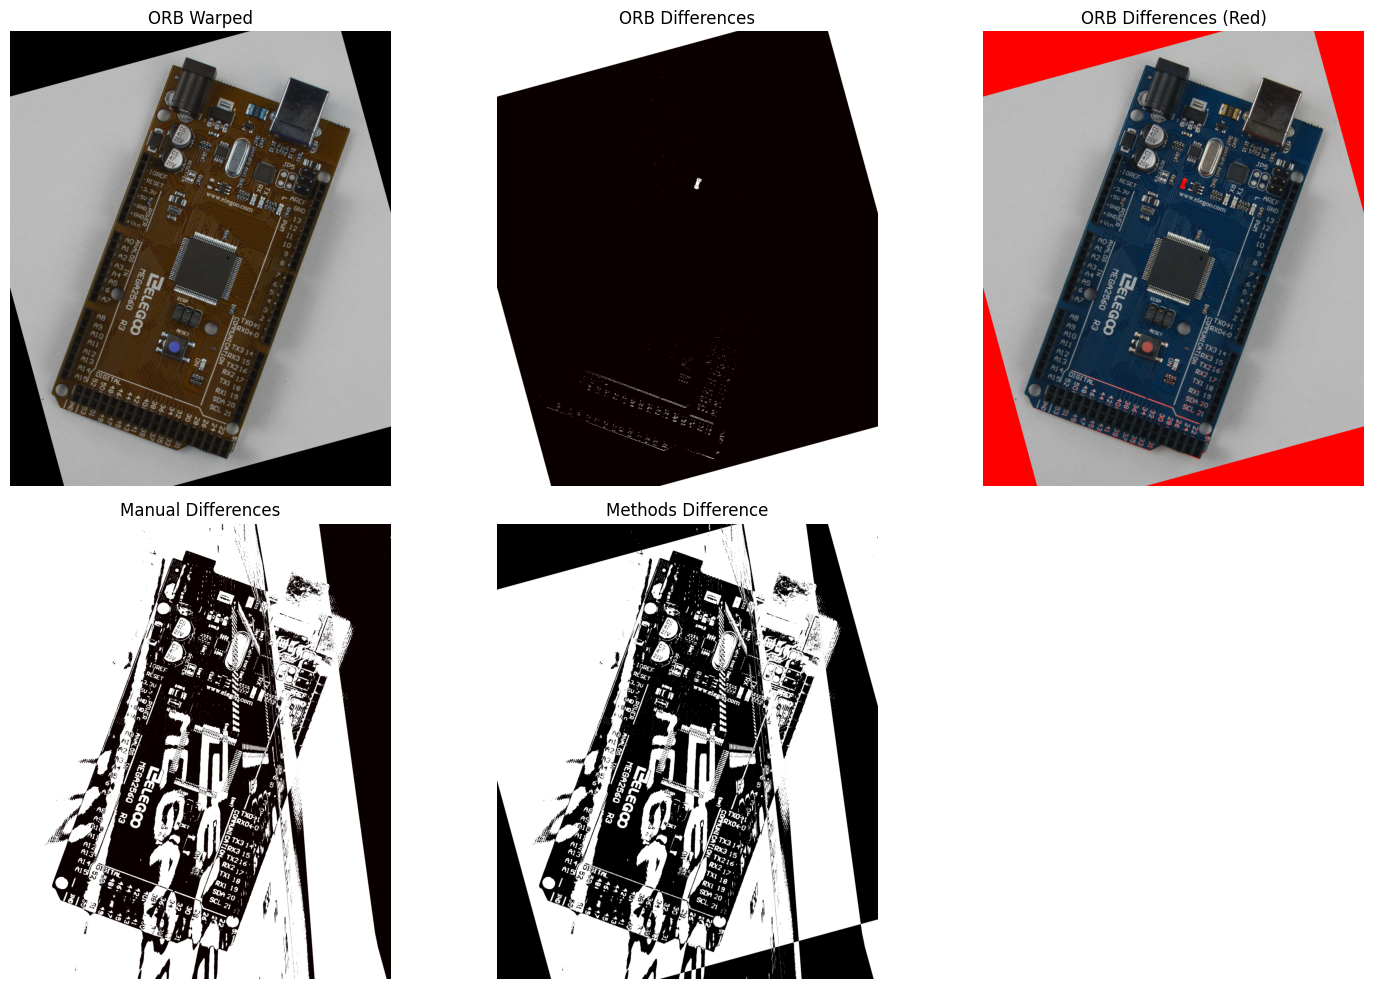


Manual differing pixels: 3938369
ORB differing pixels: 894743
ORB inliers: 731/756 (96.7%)


In [17]:
orb = cv2.ORB_create(nfeatures=1000)
kp1, des1 = orb.detectAndCompute(im1, None)
kp2, des2 = orb.detectAndCompute(im2, None)
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = sorted(bf.match(des1, des2), key=lambda x: x.distance)
print(f"ORB matches: {len(matches)}")

img_matches = cv2.drawMatches(im1, kp1, im2, kp2, matches[:50], None, flags=2)
cv2.namedWindow('ORB Matches', cv2.WINDOW_NORMAL)
cv2.resizeWindow('ORB Matches', 1400, 800)
cv2.imshow('ORB Matches', img_matches)
cv2.waitKey(0)
cv2.destroyAllWindows()

src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)
H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)

warped = cv2.warpPerspective(im2, H, (w, h))
diff = cv2.absdiff(im1_gray, cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY))
_, thresh = cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(15, 10))
plt.subplot(2,3,1)
plt.imshow(warped, cmap='gray')
plt.title('ORB Warped')
plt.axis('off')
plt.subplot(2,3,2)
plt.imshow(thresh, cmap='hot')
plt.title('ORB Differences')
plt.axis('off')
plt.subplot(2,3,3)
overlay = warped.copy()
overlay[thresh > 0] = [0,0,255]
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title('ORB Differences (Red)')
plt.axis('off')
plt.subplot(2,3,4)
plt.imshow(diff_thresh, cmap='hot') 
plt.title('Manual Differences')
plt.axis('off')
plt.subplot(2,3,5)
plt.imshow(cv2.absdiff(diff_thresh, thresh), cmap='gray')
plt.title('Methods Difference')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"\nManual differing pixels: {np.sum(diff_thresh > 0)}") 
print(f"ORB differing pixels: {np.sum(thresh > 0)}")
print(f"ORB inliers: {np.sum(mask)}/{len(matches)} ({100*np.sum(mask)/len(matches):.1f}%)")